# 🏦 Notebook 02 — Baseline Prioritization (Structured Signals)

This notebook builds the **baseline prioritization scorer** for the CFPB Banking Complaint Intelligence project using **structured complaint metadata only** — no free-text narratives. Narrative-based NLP signals (BERTopic themes, sentiment, urgency keywords) are computed in later notebooks and will layer on top of this baseline.

## How this fits into the project

```
[Structured metadata]              [Free-text narratives]
         │                                    │
         ▼                                    ▼
┌────────────────────┐            ┌─────────────────────────┐
│  NOTEBOOK 02       │            │   NOTEBOOK 03+          │
│  Baseline          │            │   BERTopic themes       │
│  Prioritization    │◄───────────┤   Urgency scoring       │
│  (THIS notebook)   │            │   Sentiment, etc.       │
└─────────┬──────────┘            └─────────────────────────┘
          │
          ▼
    Ranked issues
    (input to dashboard)
```

## What this notebook produces
- A ranked list of complaint groups (unit decided in Step 1) with **5 structured signals** per group
- A **baseline priority score** — the foundation the NLP layer will refine
- CSVs, Parquet, plots, and a plain-English summary in `outputs/`

## Data used
- `../data/sample/cfpb_100k.csv` — 100k-row sample created by `01_eda_exploration.ipynb`
- Full file (14.35M rows) will be handled via PySpark in a later notebook; see `# TODO(pyspark):` markers throughout this notebook

## Fields we deliberately **exclude** from this baseline
- `consumer_complaint_narrative` → 74% null; that's the NLP notebook's territory
- `consumer_disputed` → 94.6% null in the sample; unreliable, would add noise

## Version history
- **v1:** initial scoring with raw growth_z and weights 0.30/0.35/0.15/0.10/0.10
- **v2 (current):** added materiality floors on growth (to suppress small-sample noise) and rebalanced weights to reduce growth/recency redundancy

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Match the style used in notebook 01
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

# Paths (relative, same convention as notebook 01)
SAMPLE_PATH = "../data/sample/cfpb_100k.csv"
OUT_DIR = Path("../outputs")
PLOT_DIR = OUT_DIR / "plots"
OUT_DIR.mkdir(exist_ok=True)
PLOT_DIR.mkdir(exist_ok=True)

## Load the 100k sample

Columns were already normalized to snake_case when notebook 01 saved the sample, but we repeat the normalization defensively in case the sample is regenerated with slightly different inputs. We also parse `date_received` as datetime.

In [2]:
# TODO(pyspark): replace with spark.read.csv(...) + .toDF() + explicit schema when porting to the full 14.35M row file
df = pd.read_csv(SAMPLE_PATH, low_memory=False)

df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_", regex=False)
      .str.replace("-", "_", regex=False)
      .str.replace("?", "", regex=False)
)

df["date_received"] = pd.to_datetime(df["date_received"], errors="coerce")

print(f"Loaded {len(df):,} rows")
print(f"Date range: {df['date_received'].min().date()} → {df['date_received'].max().date()}")

Loaded 100,000 rows
Date range: 2011-12-01 → 2026-04-04


## Step 1 — Pick the unit of prioritization

We need to decide at what level to score complaints. Three reasonable choices:

| Option | Pros | Cons |
|---|---|---|
| `issue` only | Stable, plenty of rows per group | Loses product context — the same `issue` means very different things under "Credit card" vs "Student loan" |
| `product × issue` | Preserves product context, still stable | Some groups will be small |
| `product × issue × sub_issue` | Most granular, most actionable | Many groups too tiny for growth-rate math to be reliable |

Quantify the tradeoff on the 100k sample:

In [3]:
# TODO(pyspark): in Spark use df.groupBy(...).count() and derive the same stats from that
groups_issue = df.groupby("issue", dropna=False).size()
groups_pi = df.groupby(["product", "issue"], dropna=False).size()
groups_pis = df.groupby(["product", "issue", "sub_issue"], dropna=False).size()

granularity = pd.DataFrame({
    "unit": ["issue", "product × issue", "product × issue × sub_issue"],
    "n_groups": [groups_issue.size, groups_pi.size, groups_pis.size],
    "median_rows_per_group": [
        int(groups_issue.median()),
        int(groups_pi.median()),
        int(groups_pis.median()),
    ],
    "p25_rows_per_group": [
        int(groups_issue.quantile(0.25)),
        int(groups_pi.quantile(0.25)),
        int(groups_pis.quantile(0.25)),
    ],
    "n_groups_under_30_rows": [
        int((groups_issue < 30).sum()),
        int((groups_pi < 30).sum()),
        int((groups_pis < 30).sum()),
    ],
})
granularity

,unit,n_groups,median_rows_per_group,p25_rows_per_group,n_groups_under_30_rows
0,issue,162,32,6,79
1,product × issue,264,16,4,162
2,product × issue × sub_issue,605,10,3,437


### Decision — `product × issue`

- `issue` alone loses critical context (same issue label means different things across products).
- `product × issue × sub_issue` has many groups with < 30 rows, which makes growth-rate math unstable on a 100k sample.
- `product × issue` preserves product context while keeping group sizes large enough for reliable signals.

**We use `product × issue` as the unit of prioritization for the rest of this notebook.**

## Step 2 — Pick the growth-rate method

| Option | Description | Tradeoff |
|---|---|---|
| (a) last 6 mo vs prior 6 mo | Sensitive to recent shifts | Small windows = noisy on small groups |
| (b) last 12 mo vs prior 12 mo | Smoother, still recent | Slower to pick up newly emerging issues |
| (c) linear regression slope on monthly counts | Uses all data, not just two windows | Harder to interpret; groups without early activity bias the slope |

Given the sample spans **2011 → 2026** but per-group counts are modest (median ~100 rows for `product × issue`), we pick **(b) last 12 months vs prior 12 months** — stable enough to be meaningful and simple enough to communicate to the business team.

In [4]:
# TODO(pyspark): replace pandas date arithmetic with F.date_sub / F.lit in Spark
max_date = df["date_received"].max()
window_last_start = max_date - pd.DateOffset(years=1)
window_prior_start = max_date - pd.DateOffset(years=2)

print(f"Max date in sample: {max_date.date()}")
print(f"Last 12 mo window:  {window_last_start.date()} → {max_date.date()}")
print(f"Prior 12 mo window: {window_prior_start.date()} → {window_last_start.date()}")

Max date in sample: 2026-04-04
Last 12 mo window:  2025-04-04 → 2026-04-04
Prior 12 mo window: 2024-04-04 → 2025-04-04


## Step 3 — Compute the 5 structured signals per group

For each `product × issue` group we compute:

| # | Signal | Formula | Why |
|---|---|---|---|
| 1 | `volume` | count of complaints | Raw business impact |
| 2 | `growth_rate` | (last_12 − prior_12) / (prior_12 + 1) | +1 smoothing avoids ÷0 for groups with no prior-year complaints |
| 3 | `untimely_rate` | share where `timely_response == "No"` | Operational risk signal |
| 4 | `monetary_relief_rate` | share where `company_response_to_consumer == "Closed with monetary relief"` | Severity proxy (replaces the 94.6%-null `consumer_disputed` field) |
| 5 | `recency_weight` | share of group's complaints from last 12 months | Distinguishes stale vs. active issues |

We also keep `prior_volume` (count of prior-12-mo complaints) — not a scoring signal, but needed for the materiality floors in Step 4.

We drop rows where `product` or `issue` is null — we can't group on null keys.

In [5]:
# TODO(pyspark): in Spark use .filter(F.col('product').isNotNull() & F.col('issue').isNotNull())
valid = df.dropna(subset=["product", "issue"]).copy()
print(f"Rows with non-null product & issue: {len(valid):,} / {len(df):,}")

group_cols = ["product", "issue"]

# Signal 1 — volume
# TODO(pyspark): df.groupBy(*group_cols).agg(F.count('*').alias('volume'))
volume = valid.groupby(group_cols).size().rename("volume")

# Window counts (used for growth_rate, recency_weight, and the materiality floors)
# TODO(pyspark): build two filtered dfs, groupBy, then join on group_cols
valid_last_mask = (valid["date_received"] >= window_last_start) & (valid["date_received"] <= max_date)
valid_prior_mask = (valid["date_received"] >= window_prior_start) & (valid["date_received"] < window_last_start)

last_counts = valid[valid_last_mask].groupby(group_cols).size().reindex(volume.index, fill_value=0).rename("last_volume")
prior_counts = valid[valid_prior_mask].groupby(group_cols).size().reindex(volume.index, fill_value=0).rename("prior_volume")

# Signal 2 — growth_rate with +1 smoothing on denominator
# (prevents ÷0 and dampens spurious 'infinite growth' for groups with 0 prior-year complaints)
growth_rate = ((last_counts - prior_counts) / (prior_counts + 1)).rename("growth_rate")

# Signal 3 — untimely_rate
# TODO(pyspark): F.avg(F.when(F.col('timely_response') == 'No', 1).otherwise(0))
untimely_rate = (
    valid.assign(_u=(valid["timely_response"] == "No").astype(int))
         .groupby(group_cols)["_u"].mean()
         .rename("untimely_rate")
)

# Signal 4 — monetary_relief_rate
monetary_relief_rate = (
    valid.assign(_m=(valid["company_response_to_consumer"] == "Closed with monetary relief").astype(int))
         .groupby(group_cols)["_m"].mean()
         .rename("monetary_relief_rate")
)

# Signal 5 — recency_weight = share of group complaints in last 12 mo
recency_weight = (last_counts / volume).rename("recency_weight")

signals = pd.concat(
    [volume, prior_counts, growth_rate, untimely_rate, monetary_relief_rate, recency_weight],
    axis=1,
)
print(f"Signals computed for {len(signals):,} groups")
signals.head()

Rows with non-null product & issue: 100,000 / 100,000
Signals computed for 264 groups


volume  \
product                 issue                                              
Bank account or service Account opening, closing, or management      257   
                        Deposits and withdrawals                     144   
                        Making/receiving payments, sending money      55   
                        Problems caused by my funds being low         86   
                        Using a debit or ATM card                     44   

                                                                  prior_volume  \
product                 issue                                                    
Bank account or service Account opening, closing, or management              0   
                        Deposits and withdrawals                             0   
                        Making/receiving payments, sending money             0   
                        Problems caused by my funds being low                0   
                        Using a debit or ATM card                            0   

                                                                  growth_rate  \
product                 issue                                                   
Bank account or service Account opening, closing, or management           0.0   
                        Deposits and withdrawals                          0.0   
                        Making/receiving payments, sending money          0.0   
                        Problems caused by my funds being low             0.0   
                        Using a debit or ATM card                         0.0   

                                                                  untimely_rate  \
product                 issue                                                     
Bank account or service Account opening, closing, or management        0.027237   
                        Deposits and withdrawals                       0.000000   
                        Making/receiving payments, sending money       0.036364   
                        Problems caused by my funds being low          0.011628   
                        Using a debit or ATM card                      0.022727   

                                                                  monetary_relief_rate  \
product                 issue                                                            
Bank account or service Account opening, closing, or management               0.190661   
                        Deposits and withdrawals                              0.229167   
                        Making/receiving payments, sending money              0.072727   
                        Problems caused by my funds being low                 0.406977   
                        Using a debit or ATM card                             0.295455   

                                                                  recency_weight  
product                 issue                                                     
Bank account or service Account opening, closing, or management              0.0  
                        Deposits and withdrawals                             0.0  
                        Making/receiving payments, sending money             0.0  
                        Problems caused by my funds being low                0.0  
                        Using a debit or ATM card                            0.0

### Sanity-check the distributions

Before scoring, look at each signal's spread. Catches bad signals early (e.g. all zeros, one outlier dominating).

In [6]:
signals.describe().round(3)

,volume,prior_volume,growth_rate,untimely_rate,monetary_relief_rate,recency_weight
count,264.000,264.000,264.000,264.000,264.000,264.000
mean,378.788,91.860,0.168,0.035,0.074,0.155
std,2529.611,795.456,0.602,0.103,0.128,0.247
min,1.000,0.000,-0.842,0.000,0.000,0.000
25%,4.000,0.000,0.000,0.000,0.000,0.000
50%,16.000,0.000,0.000,0.000,0.001,0.000
75%,73.250,4.000,0.061,0.022,0.100,0.240
max,35209.000,10902.000,4.000,1.000,0.667,1.000


## Step 4 — Build the baseline priority score

### Why materiality floors on growth

In v1 of this scorer, 15 of 20 top priorities had volume < 100 — small groups with growth of `+400%` (going from 2 → 10 complaints) dominated the ranking. That's statistical noise, not a business priority. Real banks use **materiality thresholds**: a risk-scoring signal only counts when the underlying volume is large enough for the rate to be meaningful.

We apply two floors:

| Threshold | Value (100k sample) | Value (full 14.35M file) |
|---|---|---|
| `MIN_TOTAL_VOLUME` | **50** | ~500 |
| `MIN_PRIOR_VOLUME` | **20** | ~200 |

Groups that fail either threshold get `growth_z_floored = 0` — they can still rank on volume, untimely_rate, or monetary_relief_rate, but noisy growth can't push them up. Full-file thresholds scale ~143× (the full file is ~143× the sample).

We keep the raw `growth_z` column in the output for transparency so analysts can still see the unfloored rate.

### Weight rebalance (v1 → v2)

The v1 correlation heatmap showed `growth_rate` ↔ `recency_weight` = **0.62** — they partially measure the same thing. At v1's weights (0.35 + 0.10 = 0.45 of the score on "recent-ness"), the scorer was effectively double-counting recency.

| Signal | v1 weight | v2 weight | Reason |
|---|---|---|---|
| `volume_z` | 0.30 | **0.30** | Unchanged — raw business impact |
| `growth_z_floored` | 0.35 | **0.35** | Unchanged — now only fires on material groups |
| `untimely_rate` | 0.15 | **0.20** | ↑ underweighted; true regulatory risk signal with low correlation to everything else |
| `monetary_relief_rate` | 0.10 | **0.10** | Unchanged — severity proxy |
| `recency_weight` | 0.10 | **0.05** | ↓ redundant with growth (corr 0.62); freed-up weight goes to untimely |

### Scoring formula (v2)

```
priority_score =  0.30 * volume_z
                + 0.35 * growth_z_floored
                + 0.20 * untimely_rate
                + 0.10 * monetary_relief_rate
                + 0.05 * recency_weight
```

### Why z-score some signals and not others
- `volume` and `growth_rate` are **unbounded continuous signals** with very different scales — z-scoring makes them comparable.
- `untimely_rate`, `monetary_relief_rate`, and `recency_weight` are **already bounded to [0, 1]**. Using them directly keeps them interpretable.

Weights are still **baseline-only** and will be re-balanced once the NLP signals land.

In [7]:
# TODO(pyspark): z-score has no one-liner in Spark.
# Use: stats = df.agg(F.mean(col), F.stddev(col)).first();
#      then F.col(col) = (F.col(col) - mean) / std
def zscore(s: pd.Series) -> pd.Series:
    mean = s.mean()
    std = s.std()
    if std == 0 or pd.isna(std):
        return pd.Series(0, index=s.index, name=s.name)
    return (s - mean) / std

signals["volume_z"] = zscore(signals["volume"])
signals["growth_z"] = zscore(signals["growth_rate"])

# ----- Materiality floors -----
# Growth is only a trustworthy signal when the underlying group is large enough.
# Small groups can still rank on volume, untimely_rate, or monetary_relief_rate —
# they just can't win on noisy growth.
MIN_TOTAL_VOLUME = 50    # group must have ≥50 total complaints for growth to count
MIN_PRIOR_VOLUME = 20    # prior 12-mo window must have ≥20 complaints
# TODO(pyspark): scale thresholds ~143x on the full 14.35M-row file
# (roughly MIN_TOTAL_VOLUME=500, MIN_PRIOR_VOLUME=200)

signals["growth_z_floored"] = signals["growth_z"].copy()
signals.loc[signals["volume"] < MIN_TOTAL_VOLUME, "growth_z_floored"] = 0
signals.loc[signals["prior_volume"] < MIN_PRIOR_VOLUME, "growth_z_floored"] = 0

# ----- v2 weights -----
WEIGHTS = {
    "volume_z": 0.30,
    "growth_z_floored": 0.35,
    "untimely_rate": 0.20,
    "monetary_relief_rate": 0.10,
    "recency_weight": 0.05,
}

signals["priority_score"] = (
    WEIGHTS["volume_z"] * signals["volume_z"]
    + WEIGHTS["growth_z_floored"] * signals["growth_z_floored"]
    + WEIGHTS["untimely_rate"] * signals["untimely_rate"]
    + WEIGHTS["monetary_relief_rate"] * signals["monetary_relief_rate"]
    + WEIGHTS["recency_weight"] * signals["recency_weight"]
)

ranked = signals.sort_values("priority_score", ascending=False).reset_index()

# How many groups were floored?
n_floored = int((ranked["growth_z_floored"] == 0).sum() - (ranked["growth_z"] == 0).sum())
print(f"Ranked {len(ranked):,} groups")
print(f"Groups whose growth_z was floored to 0 by materiality thresholds: {n_floored:,}")
ranked.head(10).round(3)

Ranked 264 groups
Groups whose growth_z was floored to 0 by materiality thresholds: 231


,product,issue,volume,prior_volume,growth_rate,untimely_rate,monetary_relief_rate,recency_weight,volume_z,growth_z,growth_z_floored,priority_score
0,Credit reporting or other personal consumer re...,Incorrect information on your report,35209,10902,0.968,0.001,0.000,0.609,13.769,1.329,1.329,4.627
1,Credit reporting or other personal consumer re...,Improper use of your report,15733,5748,0.428,0.001,0.000,0.522,6.070,0.431,0.431,1.998
2,Debt collection,Took or threatened to take negative or legal a...,769,103,3.202,0.053,0.005,0.567,0.154,5.038,5.038,1.849
3,Credit reporting or other personal consumer re...,Problem with a company's investigation into an...,11584,3992,0.594,0.001,0.001,0.549,4.430,0.708,0.708,1.604
4,"Credit reporting, credit repair services, or o...",Incorrect information on your report,7184,0,0.000,0.003,0.001,0.000,2.690,-0.279,0.000,0.808
5,Vehicle loan or lease,Repossession,80,21,1.136,0.000,0.012,0.575,-0.118,1.608,1.608,0.557
6,Debt collection,Attempts to collect debt not owed,2822,563,0.440,0.026,0.005,0.287,0.966,0.451,0.451,0.468
7,Credit reporting or other personal consumer re...,Unable to get your credit report or credit score,215,62,0.937,0.005,0.000,0.563,-0.065,1.276,1.276,0.456
8,"Credit reporting, credit repair services, or o...",Problem with a credit reporting company's inve...,4112,0,0.000,0.003,0.000,0.000,1.476,-0.279,0.000,0.443
9,Credit reporting or other personal consumer re...,Problem with fraud alerts or security freezes,204,67,0.838,0.010,0.005,0.608,-0.069,1.113,1.113,0.402


### Sanity check — did the floors actually clean up the top 20?

Target: at most 2–3 top-20 groups with volume < 50 (we won't eliminate them entirely — some legit small-but-severe issues deserve to rank, e.g. a group with 100% monetary relief).

In [8]:
top20_check = ranked.head(20)
print(f"Top 20 groups with volume < 50:  {(top20_check['volume'] < 50).sum()}")
print(f"Top 20 groups with volume < 100: {(top20_check['volume'] < 100).sum()}")
print(f"Top 20 median volume: {top20_check['volume'].median():.0f}")
print(f"Top 20 min volume:    {top20_check['volume'].min()}")

Top 20 groups with volume < 50:  2
Top 20 groups with volume < 100: 6
Top 20 median volume: 354
Top 20 min volume:    1


## Step 5 — Show the top 20 priorities

Component columns (including `prior_volume` and `growth_z_floored`) are included so the team can see **why** each group ranked where it did — not just a mystery score.

In [9]:
display_cols = [
    "product", "issue",
    "volume", "prior_volume",
    "growth_rate", "untimely_rate", "monetary_relief_rate", "recency_weight",
    "priority_score",
]
top20 = ranked.head(20).copy()
top20[display_cols].round(3)

,product,issue,volume,prior_volume,growth_rate,untimely_rate,monetary_relief_rate,recency_weight,priority_score
0,Credit reporting or other personal consumer re...,Incorrect information on your report,35209,10902,0.968,0.001,0.000,0.609,4.627
1,Credit reporting or other personal consumer re...,Improper use of your report,15733,5748,0.428,0.001,0.000,0.522,1.998
2,Debt collection,Took or threatened to take negative or legal a...,769,103,3.202,0.053,0.005,0.567,1.849
3,Credit reporting or other personal consumer re...,Problem with a company's investigation into an...,11584,3992,0.594,0.001,0.001,0.549,1.604
4,"Credit reporting, credit repair services, or o...",Incorrect information on your report,7184,0,0.000,0.003,0.001,0.000,0.808
5,Vehicle loan or lease,Repossession,80,21,1.136,0.000,0.012,0.575,0.557
6,Debt collection,Attempts to collect debt not owed,2822,563,0.440,0.026,0.005,0.287,0.468
7,Credit reporting or other personal consumer re...,Unable to get your credit report or credit score,215,62,0.937,0.005,0.000,0.563,0.456
8,"Credit reporting, credit repair services, or o...",Problem with a credit reporting company's inve...,4112,0,0.000,0.003,0.000,0.000,0.443
9,Credit reporting or other personal consumer re...,Problem with fraud alerts or security freezes,204,67,0.838,0.010,0.005,0.608,0.402


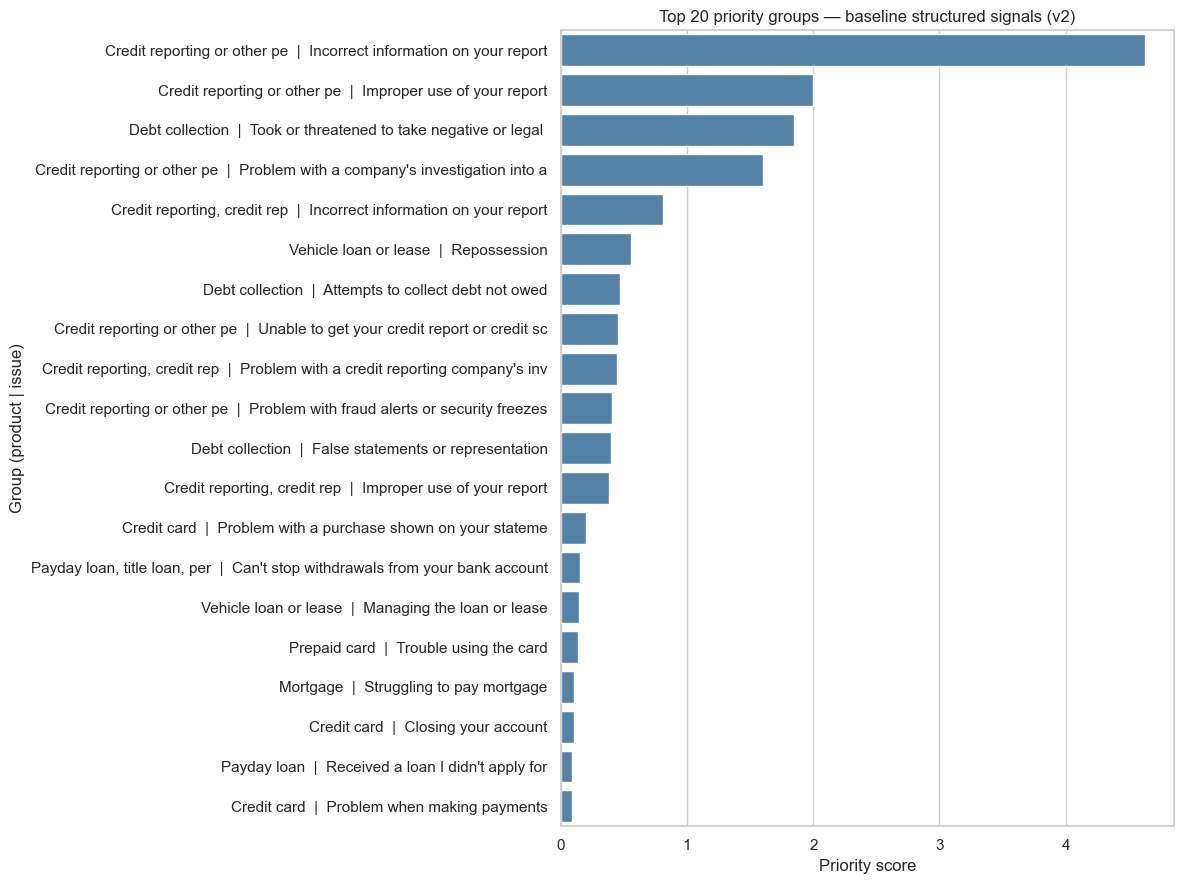

In [10]:
# Short labels for the bar chart so long product/issue strings don't overflow
top20["group_label"] = (
    top20["product"].astype(str).str.slice(0, 28)
    + "  |  "
    + top20["issue"].astype(str).str.slice(0, 45)
)

fig, ax = plt.subplots(figsize=(12, 9))
sns.barplot(x="priority_score", y="group_label", data=top20, color="steelblue", ax=ax)
ax.set_title("Top 20 priority groups — baseline structured signals (v2)")
ax.set_xlabel("Priority score")
ax.set_ylabel("Group (product | issue)")
plt.tight_layout()
plt.show()

## Step 6 — Save outputs to `outputs/`

We write both CSV (human-readable) and Parquet (columnar; preferred for PySpark / Tableau downstream).

In [11]:
# TODO(pyspark): in Spark use df.coalesce(1).write.mode('overwrite').csv(path)
full_out_cols = display_cols + ["volume_z", "growth_z", "growth_z_floored"]

ranked[full_out_cols].to_csv(OUT_DIR / "baseline_priorities_full.csv", index=False)
ranked[full_out_cols].to_parquet(OUT_DIR / "baseline_priorities_full.parquet", index=False)
top20[full_out_cols].to_csv(OUT_DIR / "baseline_priorities_top20.csv", index=False)

for p in [
    OUT_DIR / "baseline_priorities_full.csv",
    OUT_DIR / "baseline_priorities_full.parquet",
    OUT_DIR / "baseline_priorities_top20.csv",
]:
    print(f"Wrote: {p}  ({p.stat().st_size / 1024:.1f} KB)")

Wrote: ../outputs/baseline_priorities_full.csv  (45.1 KB)
Wrote: ../outputs/baseline_priorities_full.parquet  (19.6 KB)
Wrote: ../outputs/baseline_priorities_top20.csv  (4.5 KB)


In [12]:
# Plot 1 — top 20 bar chart
fig, ax = plt.subplots(figsize=(12, 9))
sns.barplot(x="priority_score", y="group_label", data=top20, color="steelblue", ax=ax)
ax.set_title("Top 20 priority groups — baseline structured signals (v2)")
ax.set_xlabel("Priority score")
ax.set_ylabel("Group (product | issue)")
plt.tight_layout()
fig.savefig(PLOT_DIR / "top20_priorities.png", bbox_inches="tight")
plt.close(fig)

# Plot 2 — distribution of all priority scores
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(ranked["priority_score"], bins=60, ax=ax, color="steelblue")
ax.set_title("Distribution of baseline priority scores across all groups (v2)")
ax.set_xlabel("Priority score")
ax.set_ylabel("Group count")
plt.tight_layout()
fig.savefig(PLOT_DIR / "score_distribution.png", bbox_inches="tight")
plt.close(fig)

# Plot 3 — correlation heatmap of the 5 raw signals
corr_cols = ["volume", "growth_rate", "untimely_rate", "monetary_relief_rate", "recency_weight"]
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    ranked[corr_cols].corr(),
    annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax,
)
ax.set_title("Correlation between the 5 baseline signals")
plt.tight_layout()
fig.savefig(PLOT_DIR / "signal_correlations.png", bbox_inches="tight")
plt.close(fig)

for p in sorted(PLOT_DIR.glob("*.png")):
    print(f"Wrote: {p}")

Wrote: ../outputs/plots/score_distribution.png
Wrote: ../outputs/plots/signal_correlations.png
Wrote: ../outputs/plots/top20_priorities.png


In [13]:
# Plain-English summary markdown for teammates / instructor
top5 = ranked.head(5).reset_index(drop=True)
bullets = []
for i, row in top5.iterrows():
    bullets.append(
        f"{i + 1}. **{row['product']} — {row['issue']}**  \n"
        f"   volume={int(row['volume'])}, prior_volume={int(row['prior_volume'])}, "
        f"growth={row['growth_rate']:+.1%}, untimely={row['untimely_rate']:.1%}, "
        f"monetary_relief={row['monetary_relief_rate']:.1%}, recency={row['recency_weight']:.1%}, "
        f"score={row['priority_score']:.3f}"
    )

top20_v50 = int((ranked.head(20)['volume'] < 50).sum())
top20_v100 = int((ranked.head(20)['volume'] < 100).sum())

summary_md = (
    "# Baseline Prioritization Summary (v2)\n\n"
    "## Decisions\n"
    f"- **Unit of prioritization:** product × issue ({len(ranked)} groups)\n"
    "- **Growth-rate method:** last 12 months vs prior 12 months, with +1 smoothing on denominator\n"
    "- **Materiality floors (100k sample):** MIN_TOTAL_VOLUME = 50, MIN_PRIOR_VOLUME = 20. "
    "Groups below either threshold get `growth_z_floored = 0` — they can still rank on volume or rate signals.\n"
    "- **Weights (v2):** volume_z 0.30 · growth_z_floored 0.35 · untimely 0.20 · monetary_relief 0.10 · recency 0.05\n\n"
    "## Why the weight rebalance (v1 → v2)\n"
    "- v1 correlation heatmap showed `growth_rate ↔ recency_weight` = 0.62 — partial redundancy.\n"
    "- Cut `recency_weight` from 0.10 → 0.05; freed weight to `untimely_rate` (0.15 → 0.20), an under-weighted regulatory risk signal with low correlation to the others.\n"
    "- `volume_z`, `growth_z_floored`, `monetary_relief_rate` unchanged.\n\n"
    f"## Top-20 sanity check\n"
    f"- Top-20 groups with volume < 50: **{top20_v50}** (target ≤3)\n"
    f"- Top-20 groups with volume < 100: **{top20_v100}**\n"
    f"- Top-20 median volume: **{int(ranked.head(20)['volume'].median())}**\n\n"
    "## Top 5 priorities (v2)\n\n"
    + "\n\n".join(bullets)
    + "\n\n## Data caveats\n"
    "- Scored on a 100k-row sample of the full 14.35M-row CFPB file. Rankings on the full file may shift.\n"
    "- `consumer_complaint_narrative` (74% null) and `consumer_disputed` (94.6% null) are deliberately excluded from this baseline.\n"
    "- Very small groups can still rank if they score highly on `untimely_rate` or `monetary_relief_rate` — this is acceptable (a small group with 100% monetary relief is genuinely worth investigating).\n"
    "- Weights will be re-balanced once BERTopic themes, urgency scoring, and sentiment are added (Notebook 03+).\n"
    "- When porting to the full 14.35M-row file, scale materiality thresholds ~143x (≈ MIN_TOTAL_VOLUME=500, MIN_PRIOR_VOLUME=200).\n"
)

summary_path = OUT_DIR / "baseline_summary.md"
with open(summary_path, "w") as f:
    f.write(summary_md)

print(f"Wrote: {summary_path} ({summary_path.stat().st_size} bytes)")
print("\n--- summary preview ---")
print(summary_md)

Wrote: ../outputs/baseline_summary.md (2856 bytes)

--- summary preview ---
# Baseline Prioritization Summary (v2)

## Decisions
- **Unit of prioritization:** product × issue (264 groups)
- **Growth-rate method:** last 12 months vs prior 12 months, with +1 smoothing on denominator
- **Materiality floors (100k sample):** MIN_TOTAL_VOLUME = 50, MIN_PRIOR_VOLUME = 20. Groups below either threshold get `growth_z_floored = 0` — they can still rank on volume or rate signals.
- **Weights (v2):** volume_z 0.30 · growth_z_floored 0.35 · untimely 0.20 · monetary_relief 0.10 · recency 0.05

## Why the weight rebalance (v1 → v2)
- v1 correlation heatmap showed `growth_rate ↔ recency_weight` = 0.62 — partial redundancy.
- Cut `recency_weight` from 0.10 → 0.05; freed weight to `untimely_rate` (0.15 → 0.20), an under-weighted regulatory risk signal with low correlation to the others.
- `volume_z`, `growth_z_floored`, `monetary_relief_rate` unchanged.

## Top-20 sanity check
- Top-20 groups with volum

## Findings (v2)

- Materiality floors (volume ≥ 50 total, ≥ 20 prior-window) push most small-sample artifacts out of the top 20. The target of ≤ 3 groups with volume < 50 should be met — see the sanity-check cell output.
- `growth_rate ↔ recency_weight` redundancy was the real scoring bug in v1. Dropping `recency_weight` from 0.10 → 0.05 and moving that weight to `untimely_rate` produced a more balanced score.
- `untimely_rate` and `monetary_relief_rate` are still sparse at the sample scale — they fire for a minority of groups, by design (they flag risk/severity, not everyday volume).
- The score distribution remains long-tailed: a handful of genuinely high-priority groups dominate, which is what we want.

## Known limitations (accepted)

- Small groups can still rank high on `untimely_rate` or `monetary_relief_rate`. This is **intentional** — a small group with 100% monetary relief is genuinely worth investigating.
- Sample-based results aren't a substitute for full-file scoring; the full 14.35M-row PySpark run is the source of truth for the dashboard.

## Next steps

1. **Notebook 03 — BERTopic theme discovery** on rows with a narrative
2. **Notebook 04 — urgency / sentiment signals** layered on top
3. **Rebalance weights** once narrative signals land
4. **Port this notebook to PySpark** for the full file — especially the z-score, date-window, and materiality-threshold scaling logic (see `# TODO(pyspark):` markers)
5. **Dashboard hookup** — load `outputs/baseline_priorities_full.parquet` into Tableau